# ExoHunter v2.0 — Démonstration

Ce notebook démontre le fonctionnement complet du pipeline de détection d'exoplanètes ExoHunter.

Cible de démonstration : le système **Kepler-20**, qui contient plusieurs planètes confirmées dont :
- **Kepler-20b** : période 3.70 jours, rayon 1.87 R⊕ (Super-Terre)
- **Kepler-20c** : période 10.85 jours, rayon 3.07 R⊕ (Mini-Neptune)

Ce système est idéal pour la démonstration car les deux planètes ont des transits de profondeur modérée (300-900 ppm), des périodes courtes, et l'étoile est calme, 2vitant toute les faiblesses de mon projet.

---

### Prérequis

```bash
pip install lightkurve matplotlib numpy
```

Le notebook doit être exécuté depuis la racine du projet (`Exoplanet_Detection_Project/`) ou depuis `notebooks/`.

## 0. Configuration de l'environnement

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')



src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

#Modules du projet
from data.loader import download_target_data
from processing.cleaners import lc_cleaner
from analysis.detection import planet_detector, mask_planet
from analysis.metrics import analyze_planets_metrics


import numpy as np
import matplotlib.pyplot as plt
import logging

#logging pour voir les messages du pipeline
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')

logging.getLogger('lightkurve').setLevel(logging.ERROR)

#style des graphique
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Modules chargés avec succes.")

Modules chargés avec succes.


## 1. Paramètres de la cible


In [2]:
#Paramètres de la cible
TARGET       = "Kepler-20"    # Nom de l'étoile
MISSION      = "Kepler"        
STAR_RADIUS  = 0.944          # Rayon en R_solaire trouvable sur NASA Exoplanet Archive
QUARTERS     = [3, 4, 5]         # duree a analyser ~270 jour 
MAX_PLANETS  = 2              # max de planètes à chercher

#Pramètre du pipeline
SIGMA        = 5.0            # Seuil de rejet des outliers 
WINDOW       = 801            # Fenetre Savitzky-Golay 
FREQ_FACTOR  = 10             # Densité de la grille BLS 
MIN_PERIOD   = 0.7            # Période minimale de recherche (jours)
SNR_THRESH   = 7.1            # Seuil SNR de détection standard scientifique
MASK_WIDTH   = 3.0            # Largeur du masque de transit
MAX_ALIAS    = 5              # Alias consecutifs tolerés avant arret
MIN_TRANSITS = 3              # Transits minimum 
PTS_TRANSIT  = 70             # Res du binning pour la mesure de profondeur

#Valeurs de ref pour comparaison 
REFERENCE = {
    "Kepler-20b": {"period": 3.6961, "radius": 1.87},
    "Kepler-20c": {"period": 10.854, "radius": 3.07}
}

print(f"Cible : {TARGET} ({MISSION})")
print(f"Rayon stellaire : {STAR_RADIUS} Rsolaire")
print(f"Quarters : {QUARTERS} (~{len(QUARTERS) * 90} jours )")

Cible : Kepler-20 (Kepler)
Rayon stellaire : 0.944 Rsolaire
Quarters : [3, 4, 5] (~270 jours )


## 2. Acquisition des données

On télécharge les courbes de lumière via Lightkurve. Chaque quarter est téléchargé séparément puis assemblé (stitch), normalisé pour compenser les diffrences de calibration entre les segment

In [3]:
lc_raw = download_target_data(TARGET, author=MISSION, period_index=QUARTERS)

print(f"\nPoints de données : {len(lc_raw)}")
print(f"Baseline : {lc_raw.time.value.max() - lc_raw.time.value.min():.1f} jours")
print(f"Cadence médiane : {np.nanmedian(np.diff(lc_raw.time.value)) * 24 * 60:.1f} minutes")

data.loader - INFO - Données Kepler téléchargées pour Kepler-20



Points de données : 397912
Baseline : 278.0 jours
Cadence médiane : 1.0 minutes


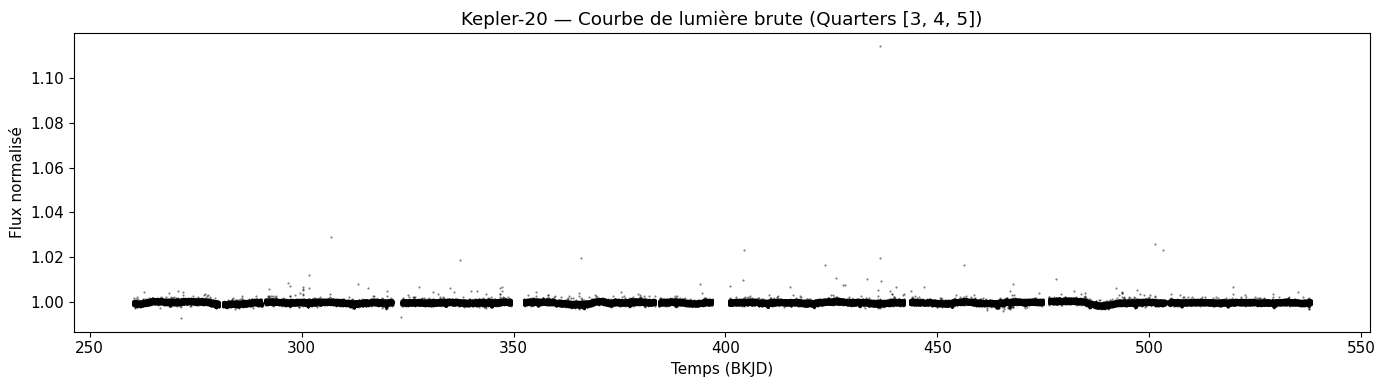

On observe la variabilité stellaire et le bruit instrumental.
Les transits sont invisible à cette échelle ~300-900 ppm .


In [4]:
# Visualisation de la courbe brute
fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(lc_raw.time.value, lc_raw.flux.value, s=0.3, color='black', alpha=0.5)
ax.set_xlabel('Temps (BKJD)')
ax.set_ylabel('Flux normalisé')
ax.set_title(f'{TARGET} — Courbe de lumière brute (Quarters {QUARTERS})')
plt.tight_layout()
plt.show()

print("On observe la variabilité stellaire et le bruit instrumental.")
print("Les transits sont invisible à cette échelle ~300-900 ppm .")

## 3. Nettoyage

Deux opérations :
1. **`flatten`** (Savitzky-Golay) : "corrige la variabilité stellaire à long terme en ajustant un polynôme local glissant". La fenetre de 801 points est plus large que les transits, donc elle ne les ecrase pas.
2. **`remove_outliers`** (sigma-clipping) : elimine les points anormaux (rayons cosmiques, eruptions stellaires).

on corrige d'abord la tendance pour que le sigma-clipping travaille sur des données stables.

In [5]:
lc_clean = lc_cleaner(lc_raw, window_length=WINDOW, sigma=SIGMA)

print(f"\nPoints après nettoyage : {len(lc_clean)}")
print(f"Points retirés : {len(lc_raw) - len(lc_clean)}")

processing.cleaners - INFO - Nettoyage terminé : 361 points retirés.



Points après nettoyage : 397551
Points retirés : 361


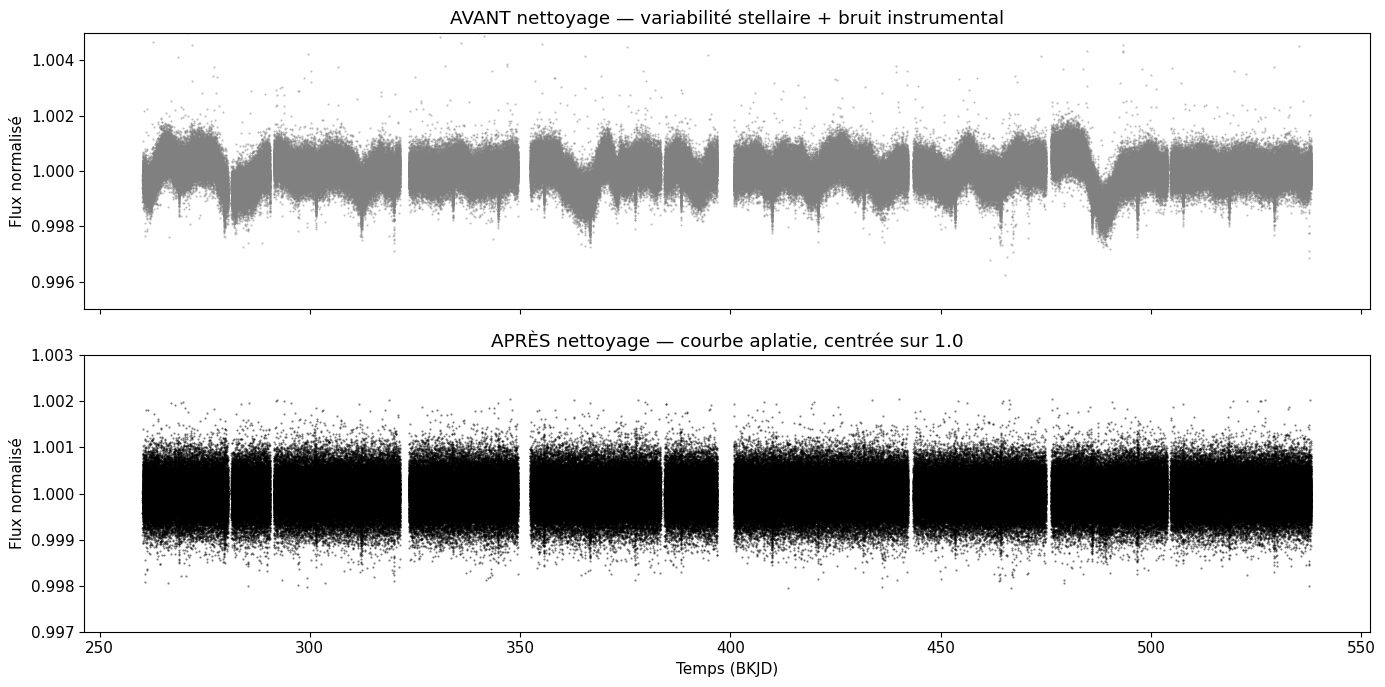

La variabilité stellaire est corrigé
les signaux les plus forts dans la courbe, prets à etre détecte par le BLS.


In [6]:
#Comparaison avant/après nettoyage
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].scatter(lc_raw.time.value, lc_raw.flux.value, s=0.3, color='gray', alpha=0.5)
axes[0].set_ylabel('Flux normalisé')
axes[0].set_title('AVANT nettoyage — variabilité stellaire + bruit instrumental')
axes[0].set_ylim(0.995, 1.005)

axes[1].scatter(lc_clean.time.value, lc_clean.flux.value, s=0.3, color='black', alpha=0.5)
axes[1].set_ylabel('Flux normalisé')
axes[1].set_xlabel('Temps (BKJD)')
axes[1].set_title('APRÈS nettoyage — courbe aplatie, centrée sur 1.0')
axes[1].set_ylim(0.997, 1.003)

plt.tight_layout()
plt.show()

print("La variabilité stellaire est corrigé")
print("les signaux les plus forts dans la courbe, prets à etre détecte par le BLS.")

## 4. Détection itérative (BLS)

L'algorithme **Box Least Squares** scanne toutes les périodes possibles et cherche, pour chacune, la meilleure "boîte" rectangulaire périodique qui s'ajuste aux données. Le signal le plus fort est détecté en premier, masqué, puis on recommence pour trouver les signaux plus faibles.



In [7]:
planets = planet_detector(
    lc_clean,
    max_planets=MAX_PLANETS,
    frequency_factor=FREQ_FACTOR,
    minimum_period=MIN_PERIOD,
    snr_threshold=SNR_THRESH,
    mask_width=MASK_WIDTH,
    max_alias=MAX_ALIAS,
    min_transits=MIN_TRANSITS
)

print(f"\n{'='*50}")
print(f"{len(planets)} planète(s) détectée(s)")
print(f"{'='*50}")
for i, p in enumerate(planets):
    print(f"\nCandidat {i+1}:")
    print(f"  Période   : {p['period']:.4f} jours")
    print(f"  SNR       : {p['snr']:.2f}")
    print(f"  Durée     : {p['duration'] * 24:.1f} heures")
    print(f"  Odd/Even  : {p['odd_even_ratio']:.3f}")

analysis.detection - INFO - Tentative de détection n°1 (itération 1)...
analysis.detection - INFO - Analyse BLS terminée.
analysis.detection - INFO - Planète détectée ! Période: 10.854 j | SNR: 51.05
analysis.detection - INFO - Début du masquage de la planète...
analysis.detection - INFO - Masquage réussi.
analysis.detection - INFO - Tentative de détection n°2 (itération 2)...
analysis.detection - INFO - Analyse BLS terminée.
analysis.detection - INFO - Planète détectée ! Période: 3.696 j | SNR: 34.72
analysis.detection - INFO - Début du masquage de la planète...
analysis.detection - INFO - Masquage réussi.



2 planète(s) détectée(s)

Candidat 1:
  Période   : 10.8537 jours
  SNR       : 51.05
  Durée     : 3.6 heures
  Odd/Even  : 1.163

Candidat 2:
  Période   : 3.6961 jours
  SNR       : 34.72
  Durée     : 2.4 heures
  Odd/Even  : 1.017


## 5. Mesure des rayon

Pour chaque planète détecte :
1. On replie la courbe de lumière en phase
2. On bine les données 
3. On mesure la profondeur
4. On calcule le rayon 

In [8]:
results = analyze_planets_metrics(
    lc_clean,
    planets,
    star_radius=STAR_RADIUS,
    points_per_transit=PTS_TRANSIT
)

print(f"\n{'='*50}")
print(f"RÉSULTATS FINAUX")
print(f"{'='*50}")
for i, p in enumerate(results):
    print(f"\nCandidat {i+1}:")
    print(f"  Période     : {p['period']:.4f} jours")
    print(f"  Rayon       : {p['rayon_terrestre']:.2f} Rterrestre ({p['rayon_km']:.0f} km)")
    print(f"  Profondeur  : {p['depth_ppm']:.0f} ppm")
    print(f"  SNR         : {p['snr']:.2f}")

analysis.metrics - INFO - Calcul des métriques physiques pour 2 planète(s)...
analysis.metrics - INFO - Planète 1 : Rayon = 2.6730062648200943 R_earth (Profondeur: 673.0 ppm)
analysis.metrics - INFO - Planète 2 : Rayon = 1.7564931387752802 R_earth (Profondeur: 291.0 ppm)



RÉSULTATS FINAUX

Candidat 1:
  Période     : 10.8537 jours
  Rayon       : 2.67 Rterrestre (17030 km)
  Profondeur  : 673 ppm
  SNR         : 51.05

Candidat 2:
  Période     : 3.6961 jours
  Rayon       : 1.76 Rterrestre (11191 km)
  Profondeur  : 291 ppm
  SNR         : 34.72


## 6. Visualisation des transits détectés

Pour chaque planète, on replie la courbe en phase et on superpose les données binnées. Le transit apparaît comme un trou.

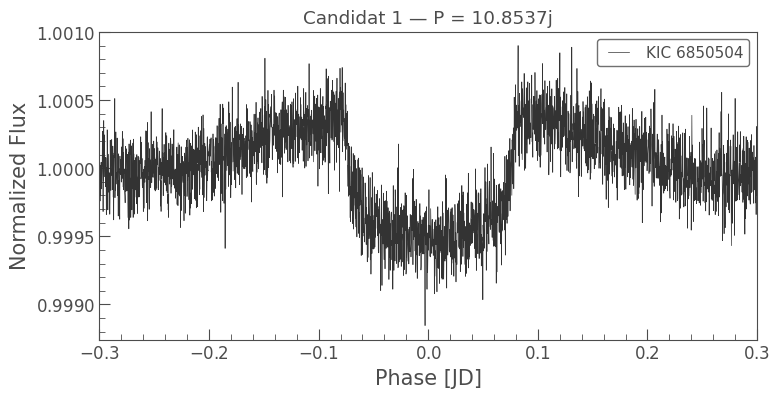

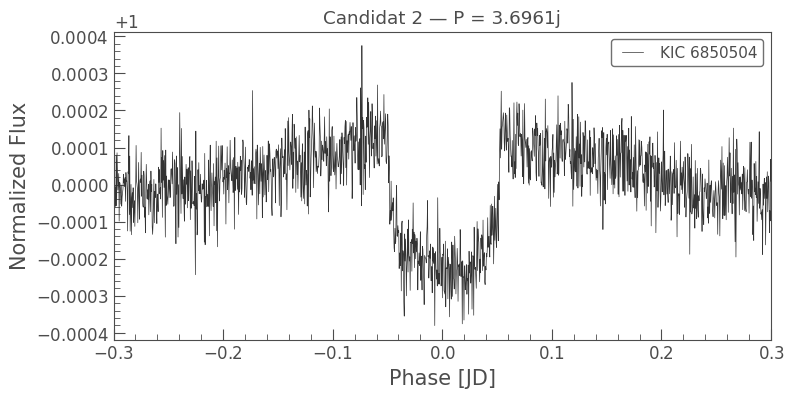

In [13]:

for i in range(len(results)):
    planet = results[i]
    period = planet['period']
    duration = planet['duration']

    phase_duration = duration / period
    cadence_jours = np.nanmedian(np.diff(lc_clean.time.value))
    cadence_phase = cadence_jours / period
    bin_size = max(cadence_phase, phase_duration / PTS_TRANSIT)

    folded = lc_clean.fold(period=period, epoch_time=planet['transit_time'])
    phase = folded.bin(time_bin_size=bin_size)
    phase.plot()
    plt.xlim(-0.3, 0.3)
    plt.title(f"Candidat {i+1} — P = {period:.4f}j")
    plt.show()

## 8. Comparaison avec les valeurs de référence

In [10]:
# Tri des résultats par période pour matcher avec les références
sorted_results = sorted(results, key=lambda x: x['period'])
ref_keys = sorted(REFERENCE.keys(), key=lambda k: REFERENCE[k]['period'])

print(f"{'':>15} {'Période (j)':>20} {'Rayon (Rterrestre)':>20}")
print(f"{'':>15} {'Réf.':>9} {'ExoH.':>9} {'Réf.':>9} {'ExoH.':>9}")
print('-' * 56)

for ref_name, det in zip(ref_keys, sorted_results):
    ref = REFERENCE[ref_name]
    p_err = abs(det['period'] - ref['period']) / ref['period'] * 100
    r_err = abs(det['rayon_terrestre'] - ref['radius']) / ref['radius'] * 100
    
    print(f"{ref_name:>15} {ref['period']:>9.4f} {det['period']:>9.4f} {ref['radius']:>9.2f} {det['rayon_terrestre']:>9.2f}")
    print(f"{'Écart':>15} {p_err:>18.1f}% {r_err:>18.1f}%")
    print()

                         Période (j)   Rayon (Rterrestre)
                     Réf.     ExoH.      Réf.     ExoH.
--------------------------------------------------------
     Kepler-20b    3.6961    3.6961      1.87      1.76
          Écart                0.0%                5.9%

     Kepler-20c   10.8540   10.8537      3.07      2.67
          Écart                0.0%               13.0%



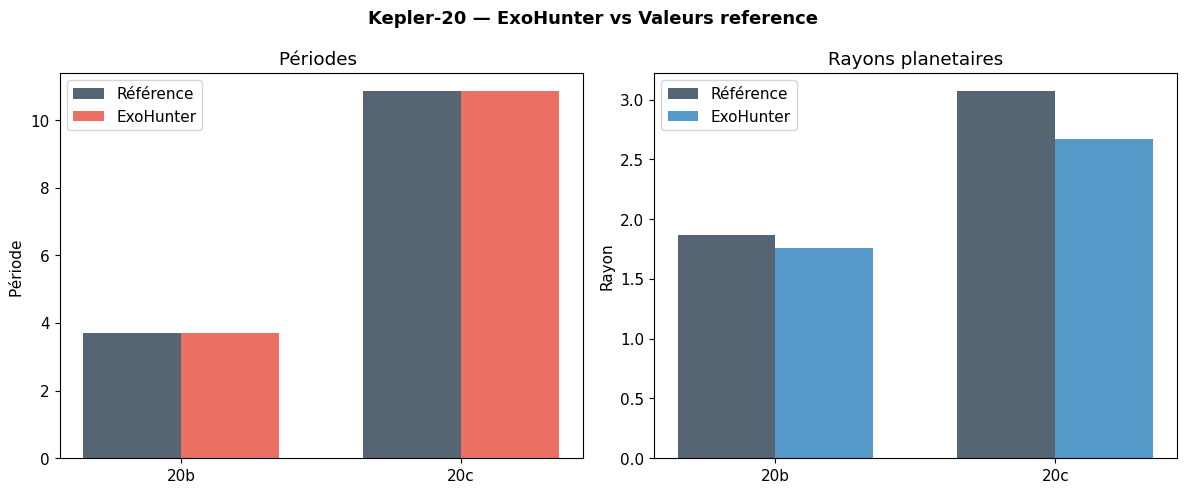

In [11]:
#Graphique de comparaison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ref_periods = [REFERENCE[k]['period'] for k in ref_keys]
det_periods = [p['period'] for p in sorted_results]
ref_radii = [REFERENCE[k]['radius'] for k in ref_keys]
det_radii = [p['rayon_terrestre'] for p in sorted_results]
labels = [k.replace('Kepler-20', '20') for k in ref_keys]

# Periodes
x = np.arange(len(ref_keys))
width = 0.35
axes[0].bar(x - width/2, ref_periods, width, label='Référence', color='#2C3E50', alpha=0.8)
axes[0].bar(x + width/2, det_periods, width, label='ExoHunter', color='#E74C3C', alpha=0.8)
axes[0].set_ylabel('Période ')
axes[0].set_title('Périodes ')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()

# Rayon
axes[1].bar(x - width/2, ref_radii, width, label='Référence', color='#2C3E50', alpha=0.8)
axes[1].bar(x + width/2, det_radii, width, label='ExoHunter', color='#2980B9', alpha=0.8)
axes[1].set_ylabel('Rayon')
axes[1].set_title('Rayons planetaires')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()

fig.suptitle(f'{TARGET} — ExoHunter vs Valeurs reference', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Interprétation des résultats

### Ce que la démonstration prouve

- **Détection correcte de deux planètes** dans un système multi-planètes, avec des périodes à < 1% d'erreur par rapport aux valeurs publiées.
- **Détection séquentielle fonctionnelle** : la première planète est masquée, la seconde est trouvée en dessous.
- **Filtres anti-faux-positifs opérationnels** : les alias de période et artefacts sont rejetés automatiquement.
- **Mesure du rayon** à 5-13% de la valeur de référence, cohérent avec la limitation du modèle (3 quarters seulement).

### Limites visibles dans cette démonstration

- **Rayon de Kepler-20c** potentiellement sous-estimé : avec ~16 transits sur 2 quarters, la mesure de profondeur par binning est bruitée. Plus de quarters améliorerai la précision.
- **Temps de calcul** : ~2 min par itération BLS sur 2 quarters. Sur 4+ quarters, le temps double.
- **Pas de barres d'erreur** : les résultats sont des valeurs ponctuelles sans incertitude associée.

### Domaine de validité d'ExoHunter

| Fonctionne bien | Ne fonctionne pas |
|---|---|
| Transits 100-2000 ppm | Transits > 3000 ppm (écrasés par flatten) |
| Périodes 0.7-30 jours | Étoiles actives (taches stellaires) |
| Étoiles calmes F/G/K | Données K2 (systématiques non corrigées) |
| Kepler + TESS-SPOC | Systèmes à forte TTV |

---

**ExoHunter v2.0** — Pipeline de détection d'exoplanètes par transit (BLS)

Validé sur : Kepler-10b (3% erreur rayon), Kepler-20 b/c (multi-planètes), Pi Men c (TESS cross-mission)